# 🌊 SST Amérique Centrale 2024–2025
### Données Copernicus Marine — OSTIA L4 NRT

**Dataset** : `METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2`  
**Région** : Amérique Centrale + Caraïbes + Pacifique Est tropical  
**Résolution** : 0.05° × 0.05° (≈ 5 km), journalière  

---
> **Prérequis** : compte gratuit sur [marine.copernicus.eu](https://marine.copernicus.eu)  
> **Connexion** : lancer une fois en terminal `copernicusmarine login`


## 0. Installation des dépendances

In [ ]:
# À lancer une seule fois
!micromamba install -c conda-forge --yes \
    copernicusmarine xarray matplotlib cartopy cmocean numpy 2>/dev/null | tail -3
print("✓ Dépendances OK")

## 1. Imports

In [ ]:
import copernicusmarine
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

OUT_DIR = Path("output_sst")
OUT_DIR.mkdir(exist_ok=True)

print("✓ Imports OK")

✓ Imports OK


## 2. Paramètres

In [24]:
# ── Région Amérique Centrale ──────────────────────────────────────
LON_MIN, LON_MAX = -100, -60
LAT_MIN, LAT_MAX =    5,  30

# ── Années d'analyse ──────────────────────────────────────────────
START_YEAR = 2023
END_YEAR   = 2024
YEARS      = list(range(START_YEAR, END_YEAR + 1))

# ── Dataset Copernicus ─────────────────────────────────────────────
#DATASET_ID = "METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2"
DATASET_ID = "METOFFICE-GLO-SST-L4-REP-OBS-SST"
VARIABLE   = "analysed_sst"

print(f"Région  : lon [{LON_MIN}, {LON_MAX}]  lat [{LAT_MIN}, {LAT_MAX}]")
print(f"Années  : {START_YEAR} → {END_YEAR}")
print(f"Dataset : {DATASET_ID}")

Région  : lon [-100, -60]  lat [5, 30]
Années  : 2023 → 2024
Dataset : METOFFICE-GLO-SST-L4-REP-OBS-SST


## 3. Téléchargement des données
Les données sont chargées en mode **lazy** (streaming via Zarr) — rien n'est téléchargé jusqu'aux calculs.

In [6]:
ds = copernicusmarine.open_dataset(
    dataset_id        = DATASET_ID,
    variables         = [VARIABLE],
    minimum_longitude = LON_MIN,
    maximum_longitude = LON_MAX,
    minimum_latitude  = LAT_MIN,
    maximum_latitude  = LAT_MAX,
    start_datetime    = f"{START_YEAR}-01-01",
    end_datetime      = f"{END_YEAR}-12-31",
)

# Kelvin → Celsius
sst = ds[VARIABLE] - 273.15
sst.attrs["units"]     = "°C"
sst.attrs["long_name"] = "Sea Surface Temperature"

print(ds)
print(f"\nDimensions : {dict(sst.sizes)}")

INFO - 2026-06-11T10:02:15Z - Selected dataset version: "202003"
INFO - 2026-06-11T10:02:15Z - Selected dataset part: "default"


<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, latitude: 500, longitude: 800)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * latitude      (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude     (longitude) float32 3kB -99.97 -99.93 -99.88 ... -60.08 -60.03
Data variables:
    analysed_sst  (time, latitude, longitude) float64 1GB dask.array<chunksize=(10, 500, 800), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T0

## 3b. Téléchargement et sauvegarde locale (NetCDF)
Télécharge les données brutes et les sauvegarde en fichiers **NetCDF** par année sur disque.  
À n'exécuter qu'une seule fois — les cellules suivantes rechargent depuis le disque si les fichiers existent déjà.

In [32]:
from pathlib import Path

DATA_DIR = Path("data_sst")
DATA_DIR.mkdir(exist_ok=True)

for year in YEARS:
    out_file = DATA_DIR / f"sst_central_america_{year}.nc"

    if out_file.exists():
        print(f"✓ {out_file} déjà présent, téléchargement ignoré.")
        continue

    print(f"⬇ Téléchargement {year}...")
    copernicusmarine.subset(
        dataset_id        = DATASET_ID,
        variables         = [VARIABLE],
        minimum_longitude = LON_MIN,
        maximum_longitude = LON_MAX,
        minimum_latitude  = LAT_MIN,
        maximum_latitude  = LAT_MAX,
        start_datetime    = f"{year}-01-01T00:00:00",
        end_datetime      = f"{year}-12-31T23:59:59",
        output_directory  = str(DATA_DIR),
        output_filename   = out_file.name,
        overwrite         = False,
    )
    print(f"✓ Sauvegardé : {out_file}  ({out_file.stat().st_size / 1e6:.1f} Mo)")

print("\n── Chargement depuis le disque ──")
import xarray as xr
ds_list = [xr.open_dataset(DATA_DIR / f"sst_central_america_{y}.nc") for y in YEARS]
ds_local = xr.concat(ds_list, dim="time")

sst = ds_local[VARIABLE] - 273.15
sst.attrs["units"]     = "°C"
sst.attrs["long_name"] = "Sea Surface Temperature"

print(f"Dimensions chargées : {dict(sst.sizes)}")
sst

✓ data_sst/sst_central_america_2023.nc déjà présent, téléchargement ignoré.
✓ data_sst/sst_central_america_2024.nc déjà présent, téléchargement ignoré.

── Chargement depuis le disque ──
Dimensions chargées : {'time': 731, 'latitude': 500, 'longitude': 800}


<xarray.DataArray 'analysed_sst' (time: 731, latitude: 500, longitude: 800)> Size: 2GB
array([[[26.18999331, 26.20999331, 26.21999331, ...,         nan,
                 nan,         nan],
        [26.19999331, 26.20999331, 26.22999331, ...,         nan,
                 nan,         nan],
        [26.20999331, 26.21999331, 26.23999331, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., 22.50999339,
         22.44999339, 22.4199934 ],
        [        nan,         nan,         nan, ..., 22.49999339,
         22.44999339, 22.4299934 ],
        [        nan,         nan,         nan, ..., 22.48999339,
         22.46999339, 22.44999339]],

       [[26.4699933 , 26.4799933 , 26.4899933 , ...,         nan,
                 nan,         nan],
        [26.4799933 , 26.4899933 , 26.4999933 , ...,         nan,
                 nan,         nan],
        [26.4999933 , 26.5099933 , 26.5099933 , ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ..., 22.0599934 ,
         22.0499934 , 22.0499934 ],
        [        nan,         nan,         nan, ..., 22.0399934 ,
         22.0199934 , 21.9999934 ],
        [        nan,         nan,         nan, ..., 21.97999341,
         21.93999341, 21.90999341]],

       [[27.40999328, 27.37999328, 27.33999329, ...,         nan,
                 nan,         nan],
        [27.38999328, 27.35999328, 27.31999329, ...,         nan,
                 nan,         nan],
        [27.35999328, 27.33999329, 27.30999329, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., 21.76999341,
         21.73999341, 21.72999341],
        [        nan,         nan,         nan, ..., 21.76999341,
         21.71999341, 21.70999341],
        [        nan,         nan,         nan, ..., 21.79999341,
         21.73999341, 21.69999341]]], shape=(731, 500, 800))
Coordinates:
  * time       (time) datetime64[ns] 6kB 2023-01-01 2023-01-02 ... 2024-12-31
  * latitude   (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude  (longitude) float32 3kB -99.97 -99.93 -99.88 ... -60.08 -60.03
Attributes:
    comment:         OSTIA foundation SST
    long_name:      Sea Surface Temperature
    reference:      C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. F...
    source:         AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P...
    standard_name:  sea_surface_foundation_temperature
    units:          °C
    valid_max:      4500
    valid_min:      -300

## 4. Calcul des moyennes mensuelles

In [33]:
sst_monthly = sst.resample(time="ME").mean()
print(f"Nombre de mois : {len(sst_monthly.time)}")
sst_monthly

Nombre de mois : 24


<xarray.DataArray 'analysed_sst' (time: 24, latitude: 500, longitude: 800)> Size: 77MB
array([[[26.50418685, 26.52128363, 26.54418685, ...,         nan,
                 nan,         nan],
        [26.49934814, 26.51128363, 26.52967072, ...,         nan,
                 nan,         nan],
        [26.49709008, 26.50321911, 26.51515459, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., 21.77450954,
         21.75612244, 21.74031599],
        [        nan,         nan,         nan, ..., 21.72612244,
         21.71031599, 21.70063857],
        [        nan,         nan,         nan, ..., 21.67709019,
         21.66676761, 21.66225148]],

       [[26.95999329, 26.97320758, 26.97963615, ...,         nan,
                 nan,         nan],
        [26.96427901, 26.97356472, 26.97713615, ...,         nan,
                 nan,         nan],
        [26.96285044, 26.96999329, 26.97142187, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ..., 24.71832668,
         24.72232668, 24.72999334],
        [        nan,         nan,         nan, ..., 24.62232668,
         24.62666001, 24.63266001],
        [        nan,         nan,         nan, ..., 24.51499335,
         24.51532668, 24.52366002]],

       [[26.81870297, 26.83257394, 26.8516062 , ...,         nan,
                 nan,         nan],
        [26.85483201, 26.86386426, 26.87967072, ...,         nan,
                 nan,         nan],
        [26.88805781, 26.89612233, 26.90902555, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., 23.23386434,
         23.20838047, 23.17515467],
        [        nan,         nan,         nan, ..., 23.16483209,
         23.13515467, 23.09515467],
        [        nan,         nan,         nan, ..., 23.0680579 ,
         23.03483209, 22.99160629]]], shape=(24, 500, 800))
Coordinates:
  * time       (time) datetime64[ns] 192B 2023-01-31 2023-02-28 ... 2024-12-31
  * latitude   (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude  (longitude) float32 3kB -99.97 -99.93 -99.88 ... -60.08 -60.03
Attributes:
    comment:         OSTIA foundation SST
    long_name:      Sea Surface Temperature
    reference:      C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. F...
    source:         AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P...
    standard_name:  sea_surface_foundation_temperature
    units:          °C
    valid_max:      4500
    valid_min:      -300

## 5. Fonction de cartographie

In [34]:
def base_map(ax, title=""):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor="#d4c9a8", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,       zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle="--", zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                      color="gray", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(range(-100, -55, 10))
    gl.ylocator = mticker.FixedLocator(range(5, 35, 5))
    if title:
        ax.set_title(title, fontsize=10, pad=6)
    return ax

print("✓ Fonction base_map définie")

✓ Fonction base_map définie


## 6. Cartes mensuelles 2023

/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib

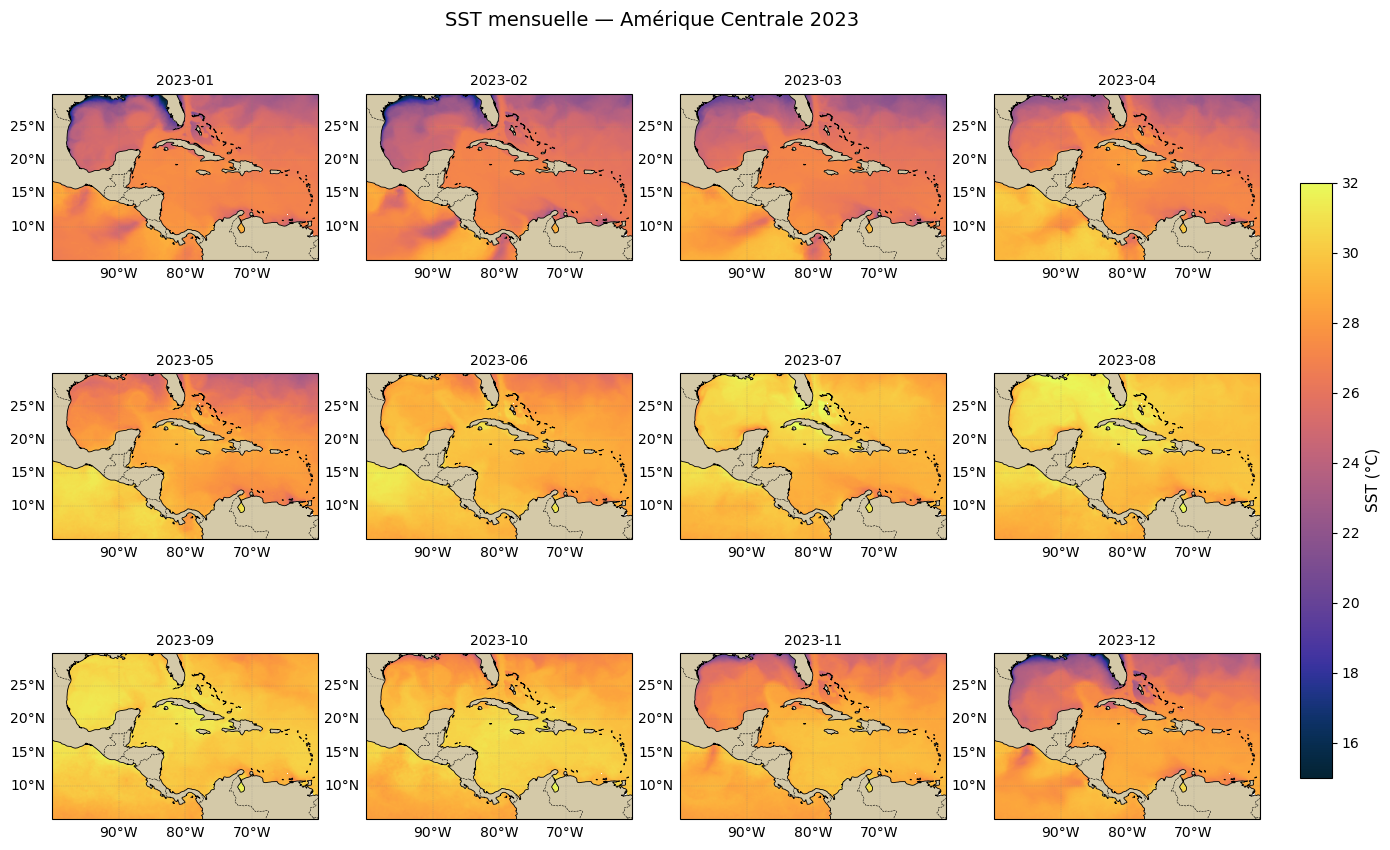

In [35]:
year = START_YEAR
sst_yr = sst_monthly.sel(time=sst_monthly.time.dt.year == year)
n_months = len(sst_yr.time)

ncols = 4
nrows = int(np.ceil(n_months / ncols))
#vmin, vmax = float(sst_yr.min()), float(sst_yr.max())
vmin, vmax = (15,32)
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 4, nrows * 3.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
axes = axes.flatten()

for i, t in enumerate(sst_yr.time.values):
    im = sst_yr.isel(time=i).plot(
        ax=axes[i], transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.thermal, vmin=vmin, vmax=vmax,
        add_colorbar=False, add_labels=False,
    )
    base_map(axes[i], title=str(t)[:7])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.subplots_adjust(right=0.88, top=0.92, wspace=0.18, hspace=0.28)
cbar_ax = fig.add_axes([0.905, 0.18, 0.02, 0.62])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("SST (°C)", fontsize=11)
fig.suptitle(f"SST mensuelle — Amérique Centrale {year}", fontsize=14, y=0.98)
fig.savefig(OUT_DIR / f"sst_monthly_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cartes mensuelles 2024

In [ ]:
year = END_YEAR
sst_yr = sst_monthly.sel(time=sst_monthly.time.dt.year == year)
n_months = len(sst_yr.time)

ncols = 4
nrows = int(np.ceil(n_months / ncols))
#vmin, vmax = float(sst_yr.min()), float(sst_yr.max())
vmin, vmax = (15,32)

nrows
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 4, nrows * 3.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
axes = axes.flatten()

for i, t in enumerate(sst_yr.time.values):
    im = sst_yr.isel(time=i).plot(
        ax=axes[i], transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.thermal, vmin=vmin, vmax=vmax,
        add_colorbar=False, add_labels=False,
    )
    base_map(axes[i], title=str(t)[:7])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.subplots_adjust(right=0.88, top=0.92, wspace=0.18, hspace=0.28)
cbar_ax = fig.add_axes([0.905, 0.18, 0.02, 0.62])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("SST (°C)", fontsize=11)
fig.suptitle(f"SST mensuelle — Amérique Centrale {year}", fontsize=14, y=0.98)
fig.savefig(OUT_DIR / f"sst_monthly_{year}.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Comparaison annuelle 2023 vs 2024

/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib

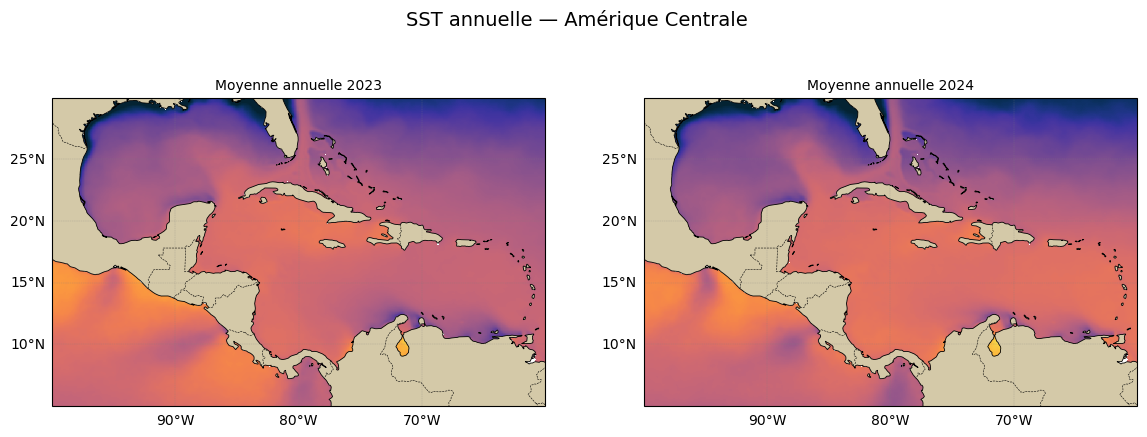

In [54]:
annual_means = {}

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for ax, year in zip(axes, [START_YEAR, END_YEAR]):
    sst_yr = sst.sel(time=sst.time.dt.year == year).mean("time")
    annual_means[year] = sst_yr
    im = sst_yr.plot(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.thermal, vmin=24, vmax=32,
        add_colorbar=False, add_labels=False,
    )
    base_map(ax, title=f"Moyenne annuelle {year}")

#fig.subplots_adjust(top=0.98, bottom=0.1, wspace=0.1)
#cbar_ax = fig.add_axes([0.22, 0.08, 0.56, 0.035])
#cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
#cbar.set_label("SST (°C)", fontsize=11)
fig.suptitle("SST annuelle — Amérique Centrale", fontsize=14, y=0.98)
fig.savefig(OUT_DIR / "sst_annual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Anomalie SST (2025 − 2024)

In [ ]:
anomalie = annual_means[END_YEAR] - annual_means[START_YEAR]
lim = float(max(abs(anomalie.min()), abs(anomalie.max())))

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
im = anomalie.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-lim, vmax=lim,
    add_colorbar=False, add_labels=False,
)
base_map(ax, title=f"Anomalie SST ({END_YEAR} − {START_YEAR})")
cbar = fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.8, pad=0.04)
cbar.set_label("ΔT (°C)", fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "sst_anomaly_2025_minus_2024.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Série temporelle (moyenne spatiale)

In [ ]:
sst_ts = sst.mean(dim=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(14, 4))
for year, color, lw in [(START_YEAR, "#2166ac", 1.4), (END_YEAR, "#d6604d", 1.4)]:
    ts = sst_ts.sel(time=sst_ts.time.dt.year == year)
    ax.plot(ts.time.values, ts.values, label=str(year), color=color, linewidth=lw)

ax.set_ylabel("SST moyenne (°C)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.set_title("Série temporelle SST — Amérique Centrale (moyenne spatiale)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "sst_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Fichiers générés

In [ ]:
for f in sorted(OUT_DIR.glob("*.png")):
    print(f"✓ {f}")